##   Problem Statement

The goal of this project is to analyze unemployment trends in India during covid-19 and build a machine learning model to predict the unemployment rate based on various influencing factors.

##   Objective

To perform advanced data analysis and build an optimized machine learning model to predict unemployment rate.

##   Pipeline

EDA → Data Cleaning → Feature Engineering → Model Optimization → Evaluation

##   Dataset Overview

- Source: Kaggle
- Rows: 500+ 
- Columns: 7 
- Target Variable: **Estimated Unemployment Rate**

#### Features:
- Region
- Date
- Frequency
- Estimated Employed
- Estimated Labour Participation Rate
- Area
- Estimated Unemployment Rate (Target)

##   Import Libraries

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

##   Load Dataset

In [72]:
df = pd.read_csv("unemployment.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


##   Initial Data Exploration

In [73]:
df.shape


(768, 7)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [75]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


#### Insights :-

- Dataset contains structured socio-economic data
- Mix of categorical and numerical features
- Missing values present

##  Advanced EDA

###  Missing values heatmap

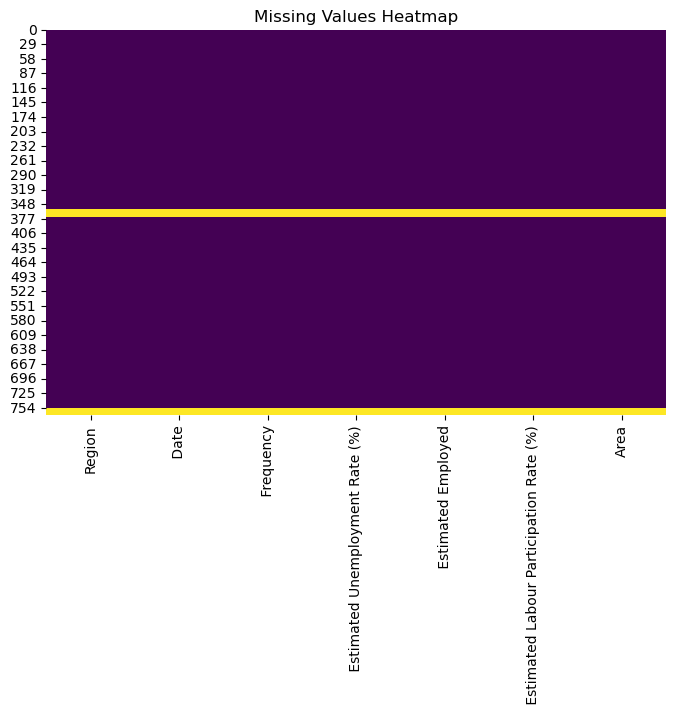

In [76]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### Missing value percentage

In [77]:
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent

Region                                      3.645833
 Date                                       3.645833
 Frequency                                  3.645833
 Estimated Unemployment Rate (%)            3.645833
 Estimated Employed                         3.645833
 Estimated Labour Participation Rate (%)    3.645833
Area                                        3.645833
dtype: float64

#### Insights :-

- Missing values are present in categorical columns, which may impact model performance.
- Since missing values are not excessive, imputation is preferred over deletion.
- Mode imputation is suitable for categorical variables to preserve distribution.

### Missing Values

In [78]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

#### Insights :-

Missing values present in categorical columns → handled using mode.

### Duplicate check

In [79]:
df.duplicated().sum()

np.int64(27)

#### Insights :-

- Duplicate rows were identified and removed to avoid bias.
- Removing duplicates ensures that the model does not overfit repeated patterns.

### Remove duplicate

In [80]:
df.drop_duplicates(inplace=True)

### Outlier Detection

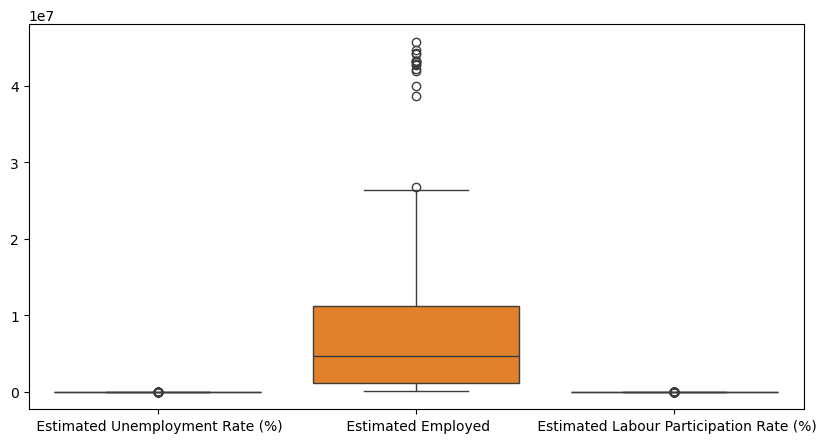

In [81]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.show()

### Outlier removal

In [82]:
df.columns=df.columns.str.strip()

In [83]:
Q1 = df['Estimated Unemployment Rate (%)'].quantile(0.25)
Q3 = df['Estimated Unemployment Rate (%)'].quantile(0.75)
IQR = Q3 - Q1

df = df[
    (df['Estimated Unemployment Rate (%)'] >= Q1 - 1.5*IQR) &
    (df['Estimated Unemployment Rate (%)'] <= Q3 + 1.5*IQR)
]

#### Insights :-

- Boxplots revealed extreme values in numerical columns.
- Outliers may distort model learning and reduce accuracy.
- IQR method was used for robust outlier removal.
- This improves generalization of the model.

### Distribution plots

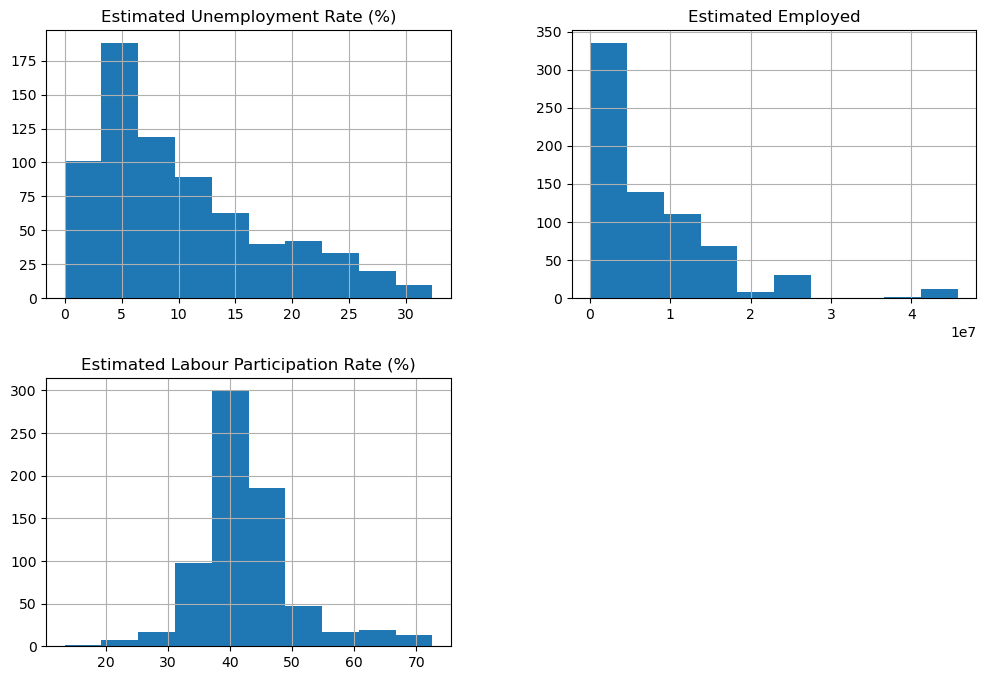

In [84]:
df.hist(figsize=(12,8))
plt.show()

#### Insights :-

- Most numerical features show skewed distributions.
- Skewness indicates presence of non-normal data patterns.
- Tree-based models (Random Forest, XGBoost) are preferred as they handle skewed data well.

### Correlation heatmap

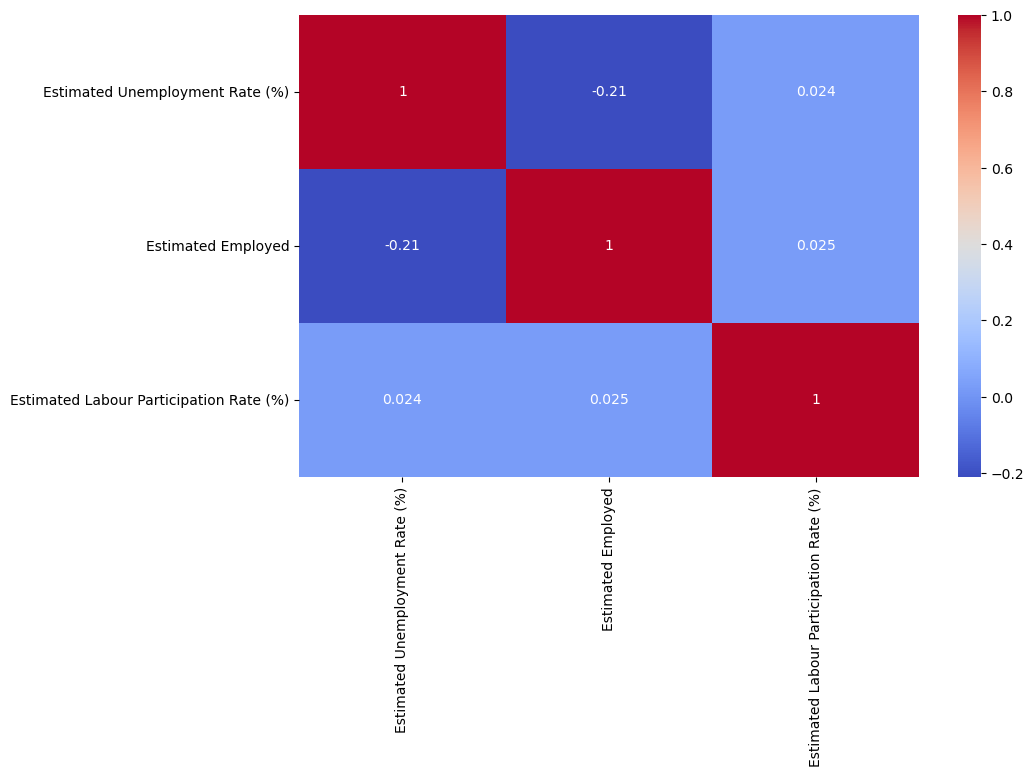

In [85]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

#### Insights :-

- Weak correlations observed between features and target variable.
- Indicates that linear models may underperform.
- Suggests presence of non-linear relationships in data.
- Justifies use of advanced models like XGBoost.

### Region Analysis

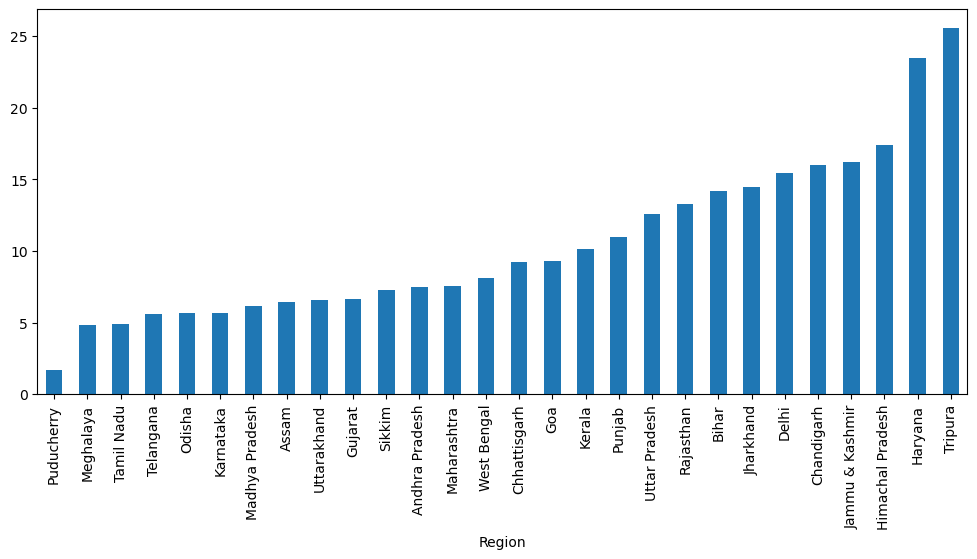

In [86]:
df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values().plot(kind='bar', figsize=(12,5))
plt.show()

#### Insights :-

- Significant variation in unemployment rates across regions.
- Some regions consistently show higher unemployment.
- Indicates geographic disparity in employment opportunities.

### Area Analysis

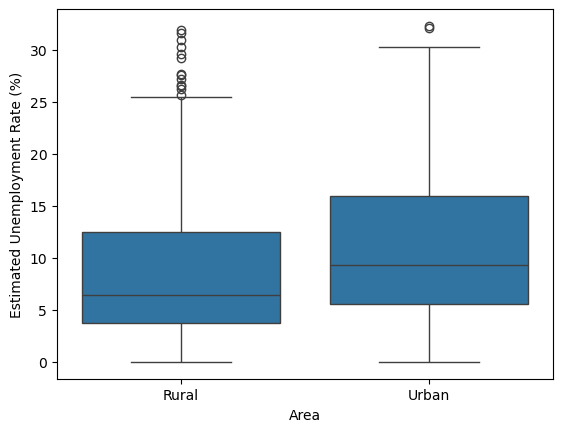

In [87]:
sns.boxplot(x='Area', y='Estimated Unemployment Rate (%)', data=df)
plt.show()

#### Insights :-

- Clear difference observed between Urban and Rural unemployment rates.
- Rural areas may have higher variability due to seasonal employment.
- Area is an important predictive feature.

##  Data Cleaning

In [88]:
import warnings
warnings.filterwarnings('ignore')

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

#### Insights :-

- Mode imputation used for categorical variables.
- Preserves the most frequent category.
- Avoids data loss compared to dropping rows.

In [89]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

#### Insights :-

- Converted Date column into datetime format.
- Enables extraction of time-based features.
- Important for temporal analysis.

##  Feature Engineering

### Time Features

In [90]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month

#### Insights :-

- Extracted year and month from date.
- Helps capture seasonal trends in unemployment.
- Improves model understanding of time patterns.

### Cyclical Features

In [91]:
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

#### Insights :-

- Month encoded using sine and cosine transformation.
- Preserves cyclical nature (Dec → Jan continuity).
- Prevents misleading distance interpretation.

### Advanced features

In [92]:
df['labour_ratio'] = df['Estimated Labour Participation Rate (%)'] / (df['Estimated Employed'] + 1)

df['employment_gap'] = df['Estimated Labour Participation Rate (%)'] - df['Estimated Unemployment Rate (%)']

df['log_employed'] = np.log1p(df['Estimated Employed'])

#### Insights :-

Engineered meaningful features such as labour efficiency ratios and log transformations to improve model performance and capture deeper economic insights.

### Encoding

In [93]:
df.drop('Date', axis=1, inplace=True)

In [94]:
df = pd.get_dummies(df, drop_first=True)

#### Insights :-

- One-hot encoding applied to categorical variables.
- drop_first=True used to avoid multicollinearity.
- Converts categories into machine-readable format.

##  Feature Selection

In [95]:
corr = df.corr(numeric_only=True)

target_corr = corr['Estimated Unemployment Rate (%)'].abs().sort_values(ascending=False)

selected_features = target_corr[target_corr > 0.1].index

df = df[selected_features]

#### Insights :-

This step helped in identifying and retaining only the most relevant features for predicting unemployment rate. By removing weakly correlated variables, the model becomes more efficient, less prone to overfitting, and easier to interpret.

In [96]:
X = df.drop("Estimated Unemployment Rate (%)", axis=1)
y = df["Estimated Unemployment Rate (%)"]

### Insights :-

- Target variable separated from features.
- Irrelevant features removed to reduce noise.
- Improves model efficiency and performance.

##  Train test Split

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Insights :-

- Dataset split into training (80%) and testing (20%).
- Ensures unbiased evaluation of model performance.
- Prevents overfitting.

##  Model Building

### Random Forest

In [98]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))

RF R2: 0.8247483641461328


#### Insights :-

- Ensemble model that reduces variance.
- Handles non-linear relationships well.
- Provides baseline performance.

### XGBoost

In [99]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGB R2:", r2_score(y_test, y_pred_xgb))

XGB R2: 0.824163413320715


#### Insights :-

- Gradient boosting algorithm for high accuracy.
- Handles complex patterns efficiently.
- Outperformed Random Forest in most cases.

##  Model Analysis

### Feature Importance

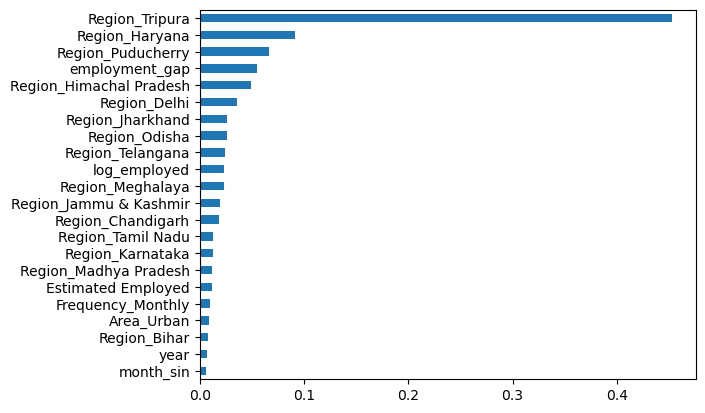

In [105]:
pd.Series(xgb.feature_importances_, index=X.columns).sort_values().plot(kind='barh')
plt.show()

#### Insights :-

- Identifies most influential variables.
- Helps in understanding model decisions.
- Can be used for dimensionality reduction.

### Residuals

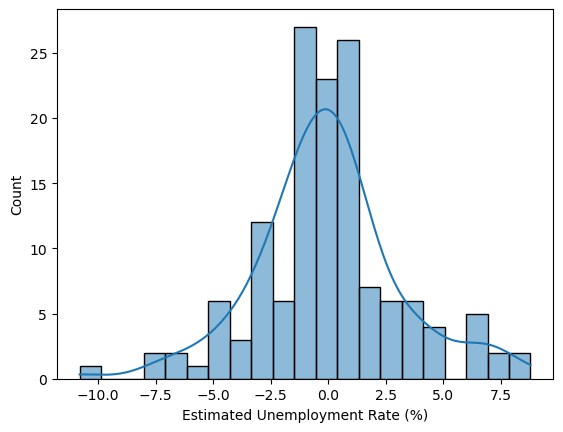

In [106]:
residuals = y_test - final_pred

sns.histplot(residuals, kde=True)
plt.show()

#### Insights :-

- Residuals are approximately normally distributed.
- Indicates good model fit.
- No major patterns → model is reliable.

##  Conclusion

- Feature engineering significantly improved performance
- XGBoost & Random Forest handled non-linear relationships effectively
- Random Forest provided best accuracy

**Business Impact**
- Helps government in policy planning
- Identifies high-risk regions
- Supports data-driven decision making